In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# file_name = "WA0089_850V_20MHz_Cold_led1"
file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-1.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-2.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-3.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-4.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-5.h5
Number of files loaded: 5


### if and where to save plots

In [3]:
save_plots = True
save_dir = 'plots_selection'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 100.0)
fit_nbins = 250



In [5]:
chunk_size = 512 #4096

baseline_window_width_ns          = cfg.general.baseline_window_width_ns
integration_window_ns             = cfg.general.integration_window_ns

# refactor: make this one variable
peak_search_window_ns             = cfg.general.peak_search_window_ns  
allowed_peak_window_ns            = cfg.general.allowed_peak_window_ns
# peak_time_window_mV = 
out_of_window_peak_voltage_max_mV = cfg.general.out_of_window_peak_voltage_max_mV
# peak_finding_threshold_mV = 

selection_peak_threshold_max_mV        = cfg.general.global_peak_voltage_max_mV
# baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + config["baseline_window_width_ns"]))



In [6]:
max_sample_events = 2

sample = read_waveform_sample(files, max_events=max_sample_events)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -0.030 to 99.970 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# 2. Full Sample


In [7]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

prerocessed_data.keys()



Preprocessed sample: (157891, 1601)
Efficiency of saturation cut: 99.672 %


dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

In [8]:
prerocessed_data['event_info'].keys()

dict_keys(['is_saturated', 'n_saturated_samples', 'baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns'])

[PosixPath('plots_selection/WA0089_850V_20MHz_Cold_led2_basline_quality.pdf')]

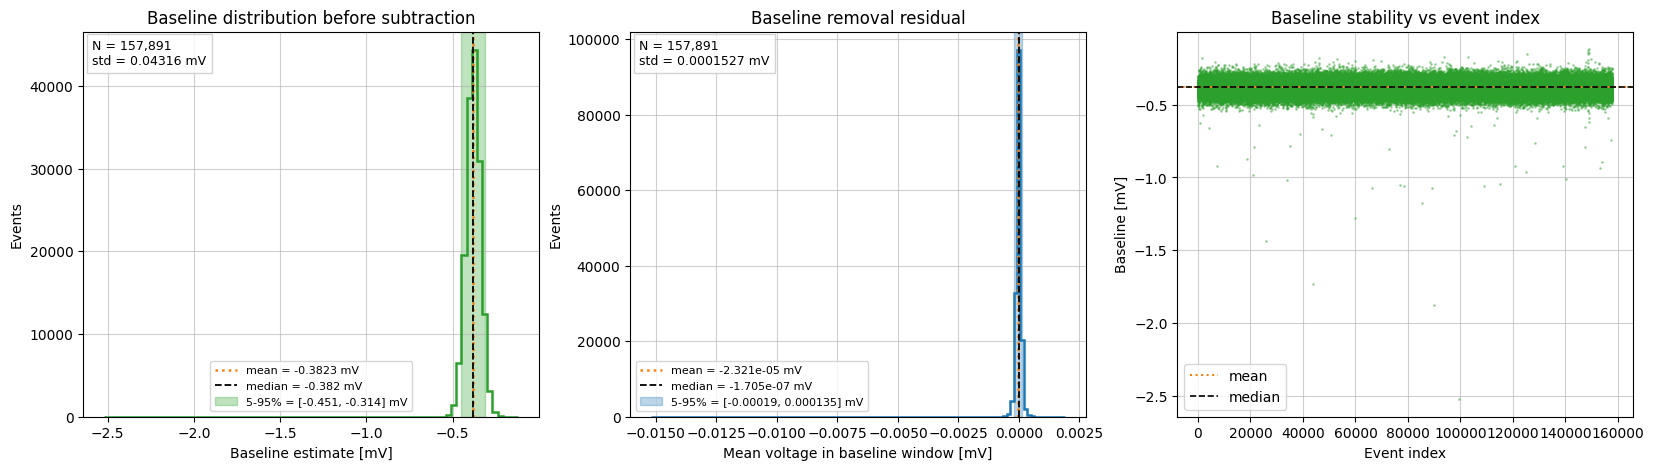

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_baseline_quality(axes, time_ns, prerocessed_data['event_info']['baseline_mean_mV'], voltage_mV, baseline_window_ns)
save_plot(fig, save_plots, save_dir, file_nickname, f"basline_quality",  Nevents=None)

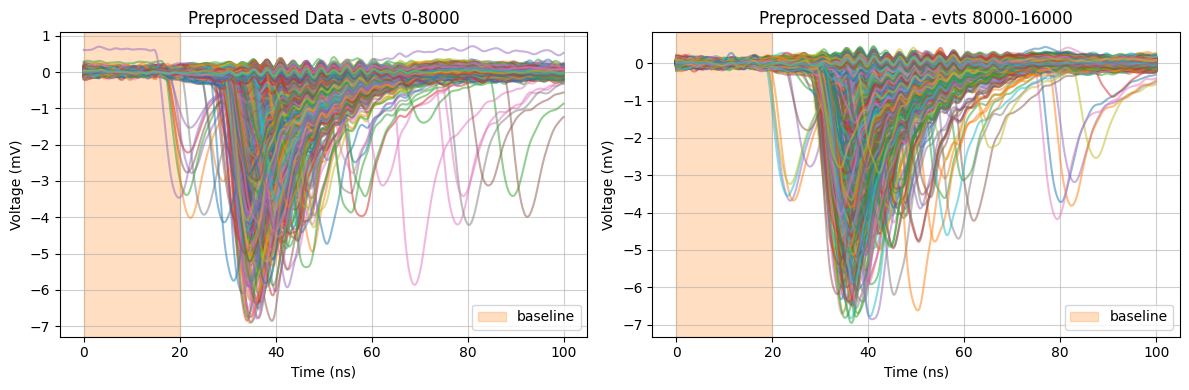

In [10]:
n_to_plot = 8000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, voltage_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, voltage_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

# Selection

In [11]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


,peak_time_ns,peak_idx,peak_amplitude_mV,fwhm_ns,peak_width_ns,rise_time_10_90_ns,fall_time_90_10_ns,cfd10_rise_ns,cfd20_rise_ns,cfd30_rise_ns,...,charge_cfd50_window_mV_ns,n_peaks,second_peak_time_ns,second_peak_amplitude_mV,peak_separation_ns,event_id,baseline_mean_mV,baseline_rms_mV,baseline_slope_mV_per_ns,snr
0,53.407237,855,0.133049,41.8125,1.483136,44.968057,0.562425,-0.030263,0.338708,0.791595,...,0.906343,43,45.032237,0.122572,-8.3750,0,-0.418997,0.027016,0.002594,4.924827
1,59.032237,945,0.083524,68.0000,1.789887,52.477631,0.668679,6.370041,6.633874,6.837885,...,-1.093133,38,85.594737,0.076040,26.5625,1,-0.412498,0.022496,-0.001231,3.712772
2,36.344737,582,4.057776,7.0625,7.168618,3.292477,16.611516,31.737239,32.188237,32.559314,...,42.258137,3,44.719737,1.311320,8.3750,2,-0.390287,0.033784,-0.003673,120.109579
3,64.157237,1027,0.156807,77.8125,2.464282,34.405312,8.475648,12.990618,13.511531,16.023041,...,5.248561,75,64.032237,0.156594,-0.1250,3,-0.332800,0.039892,-0.006171,3.930788
4,47.657237,763,0.147452,44.5625,1.512899,40.301131,0.572925,7.102610,12.448940,17.437350,...,1.470453,48,44.907237,0.108535,-2.7500,4,-0.351136,0.029333,-0.003556,5.026797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157886,53.219737,852,0.155323,9.0625,1.809144,39.980769,0.659571,13.005300,14.219203,14.816829,...,-0.894967,23,50.282237,0.112343,-2.9375,157886,-0.345832,0.025578,-0.003515,6.072554
157887,50.219737,804,0.158713,37.6250,2.100316,41.861548,0.664479,8.068959,12.211527,12.717383,...,-1.689525,37,53.219737,0.144814,3.0000,157887,-0.376227,0.035183,-0.005154,4.511069
157888,53.344737,854,0.171345,25.8750,1.516790,53.051913,0.820237,-0.030263,-0.030263,-0.030263,...,1.327985,50,61.594737,0.114893,8.2500,157888,-0.385406,0.041147,0.000233,4.164166
157889,53.157237,851,0.112130,62.8125,1.458842,49.207196,0.566008,3.703658,3.820413,3.953373,...,-0.265123,30,50.282237,0.082408,-2.8750,157889,-0.389452,0.030679,0.000141,3.654975


In [12]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject

[PosixPath('plots_selection/WA0089_850V_20MHz_Cold_led2_waveforms_after_sanity_cut.pdf')]

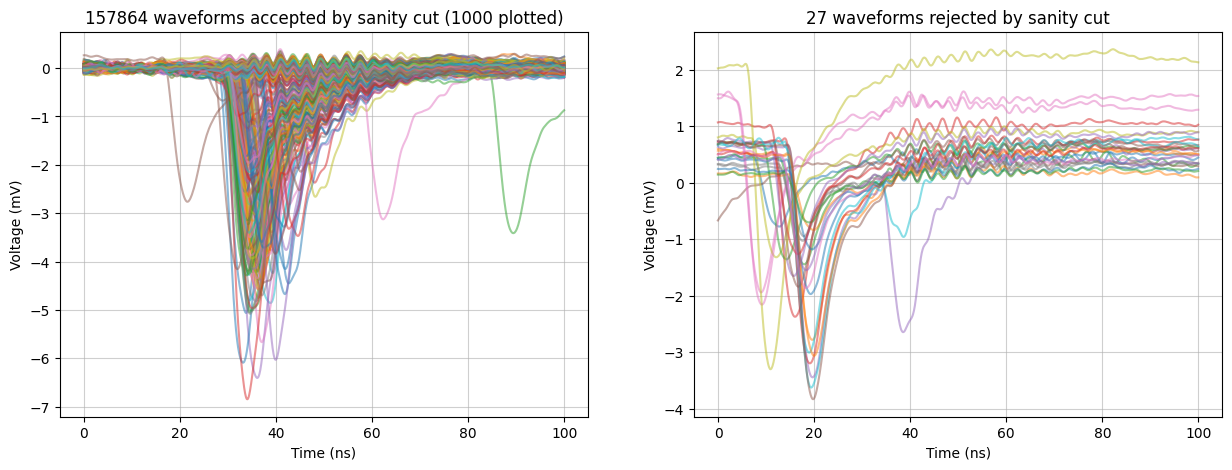

In [13]:
nEvts_plot = 1000
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()
rejected_waveforms = voltage_mV[sanity_mask_reject.values]
selected_waveforms = voltage_mV[sanity_mask_keep.values]

add_plot_waveforms(axes[0], time_ns, selected_waveforms[:nEvts_plot], title=f"{len(selected_waveforms)} waveforms accepted by sanity cut ({nEvts_plot} plotted)")
add_plot_waveforms(axes[1], time_ns, rejected_waveforms, title=f"{len(rejected_waveforms)} waveforms rejected by sanity cut")
save_plot(fig, save_plots, save_dir, file_nickname, f"waveforms_after_sanity_cut",  Nevents=None)

In [14]:
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_mV[df_sel["event_id"].values]

[PosixPath('plots_selection/WA0089_850V_20MHz_Cold_led2_snr_repport.pdf')]

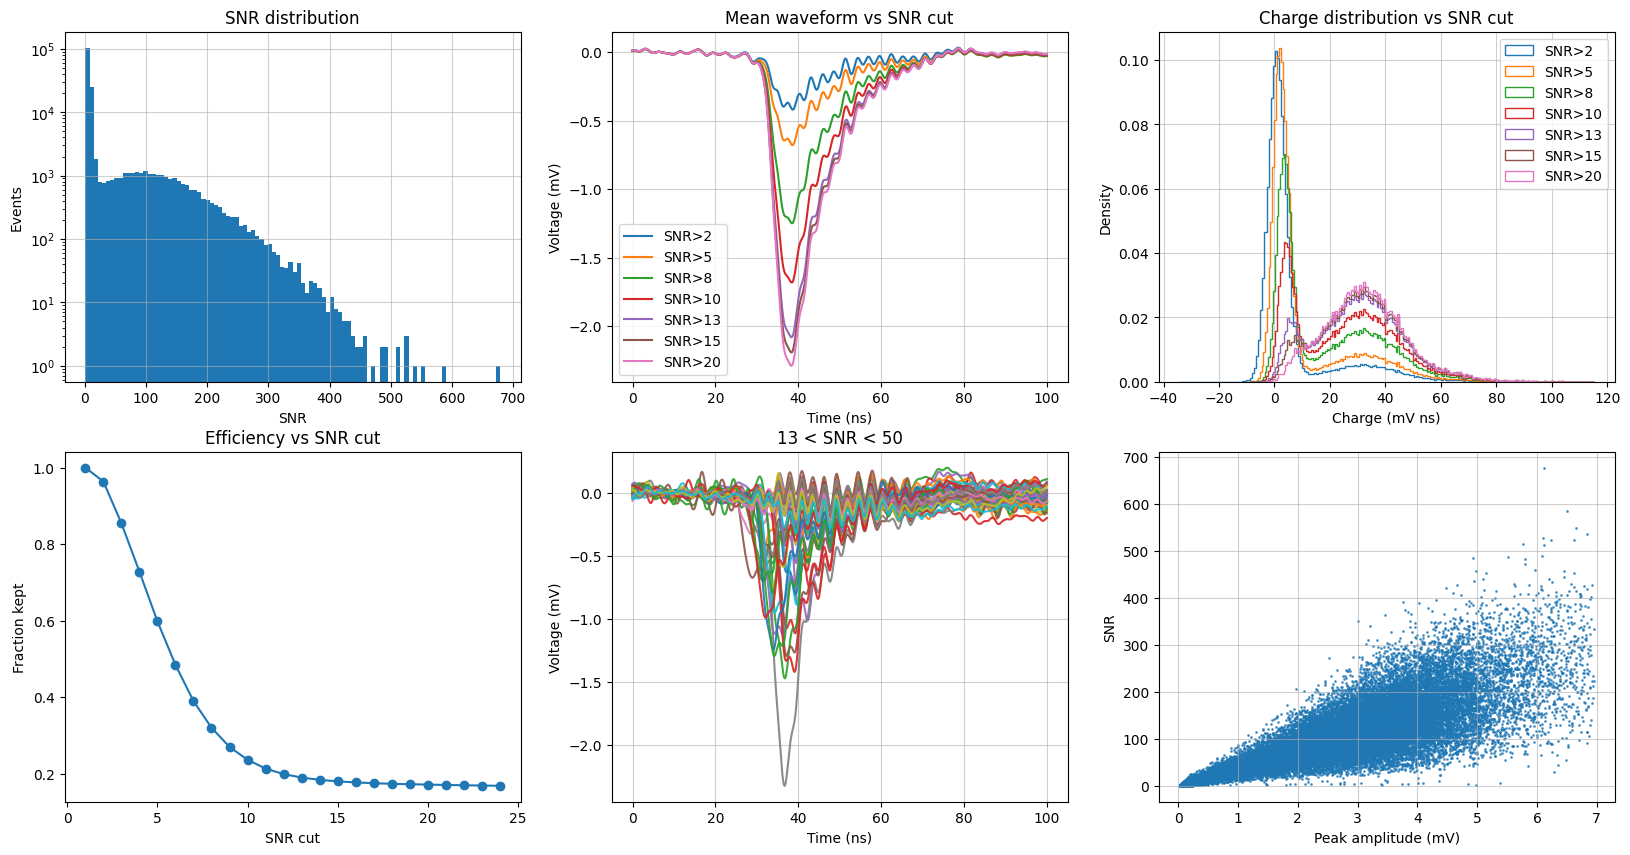

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df_sel)
plot_mean_waveforms_vs_snr(axes[1], df_sel, waveforms_sel, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df_sel, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df_sel, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df_sel, waveforms_sel, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df_sel)  
save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None)

# Charge Computation

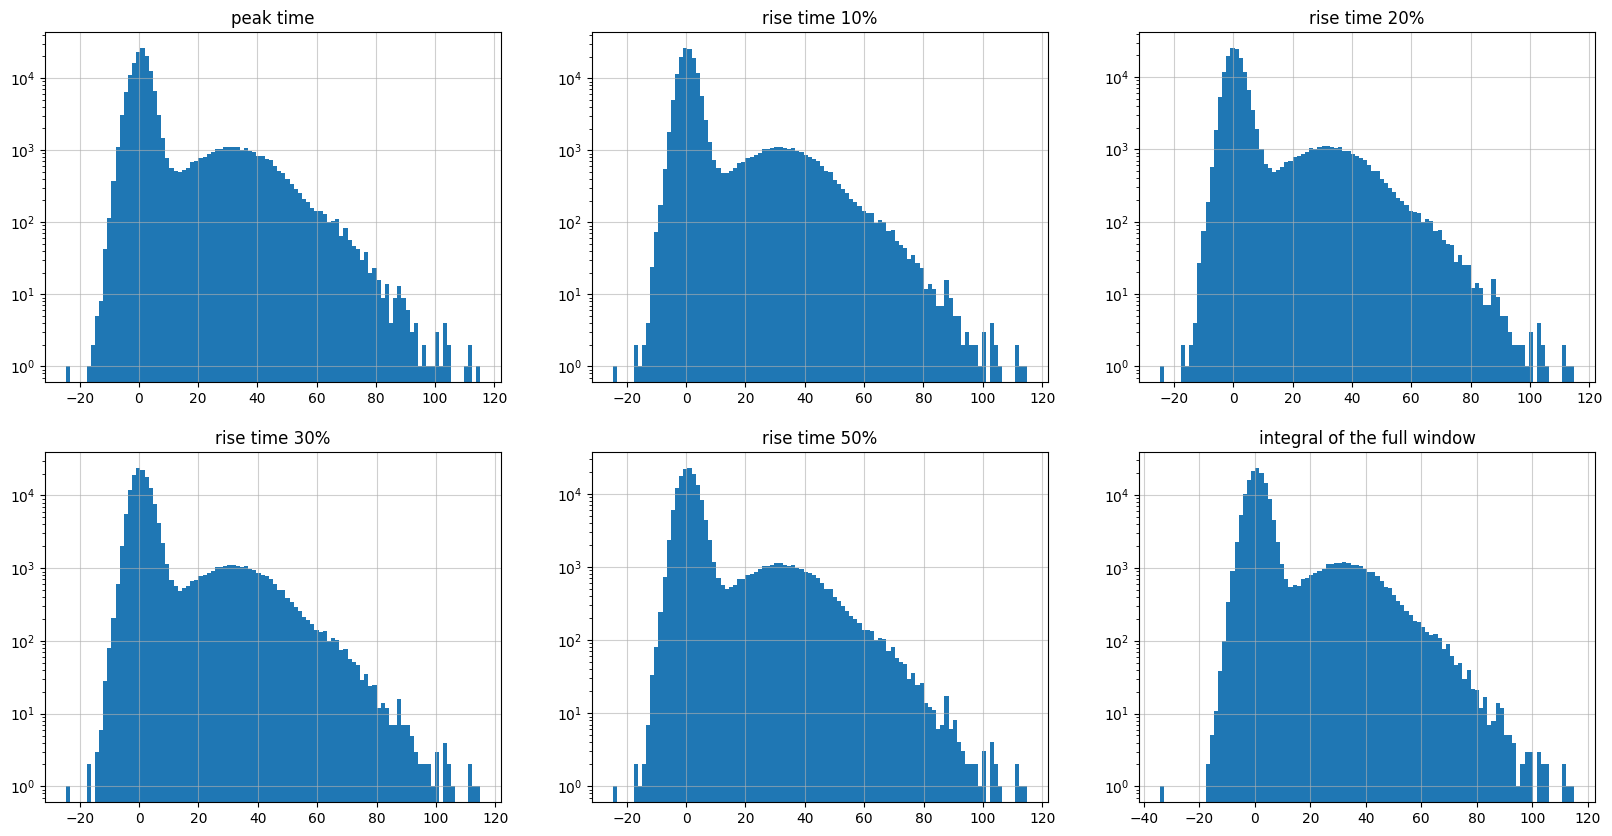

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

rg = None #(-20, 10)

axes[0].hist(df_sel.charge_peak_window_mV_ns, bins=100, range=rg);
axes[0].set_title("peak time")
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg);
axes[1].set_title("rise time 10%");
axes[2].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg);
axes[2].set_title("rise time 20%");
axes[3].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg);
axes[3].set_title("rise time 30%");
axes[4].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg);
axes[4].set_title("rise time 50%");
axes[5].hist(df_sel.area_mV_ns, bins=100, range=rg);
axes[5].set_title("integral of the full window");

for i in range(0, 6):
    axes[i].set_yscale('log')


[PosixPath('plots_selection/WA0089_850V_20MHz_Cold_led2_charge_all_methods.pdf')]

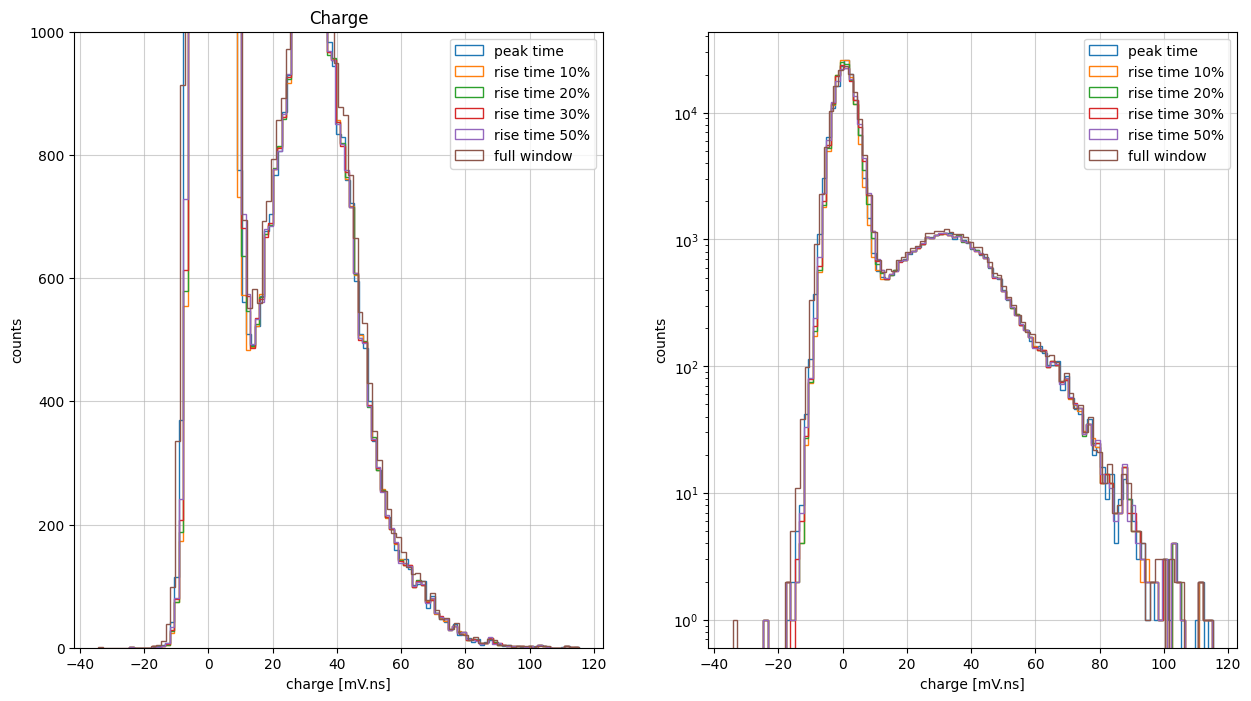

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))


rg = None #(-20, 10)
den=False

axes[0].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[0].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[0].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[0].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[0].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[0].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[0].set_ylim(0, 1000)
axes[0].set_title('Charge')
axes[0].set_ylabel('counts')
axes[0].set_xlabel('charge [mV.ns]')
axes[0].legend();

axes[1].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[1].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[1].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[1].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[1].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[1].set_xlabel('charge [mV.ns]')
axes[1].set_ylabel('counts')
axes[1].set_yscale('log');
axes[1].legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None)

